In [10]:
import numpy as np
from numpy import random
import numba as nb
import matplotlib.pyplot as plt

In [11]:
from scipy.optimize import curve_fit
def power_law(x,gamma,A):
    return A/x**gamma
def linear(x,gamma,A):
    return -gamma*x+np.log10(A)
def lin_plus_cut(x,gamma,A,C):
    return linear(x,gamma,A)-10**(x)/C
def power_cutoff(x,gamma,A,C):
    return A/x**gamma*np.exp(-x/C)

In [12]:
# does not work with numba
def topple(array,count):
     mask = np.copy(array)>1
     N = np.shape(array)[0]
     frustration = np.sum(mask)
     count += frustration
     # create new array with update values to be added to array
     update_array = np.zeros_like(array)
     # Make tuple of indecies of active sites
     # for each active site, generate two random neighbours to gift unit
     update_array[mask]+=-2
     move_list = [[-1,0],[1,0],[0,-1],[0,1]]
     for k in range(2):
        neighbour_grid = np.empty((N,N))
        neighbour_grid[mask] = np.floor(4*random.rand())
        for l in range(4):
            i_mask = mask*(neighbour_grid==l)
            indecies = np.where(i_mask)
            x=indecies[0]+move_list[l][0]
            y=indecies[1]+move_list[l][1]
            update_array[x,y]+=1
            
     array += update_array
     array[:,0] = 0
     array[:,-1] = 0
     array[0,:] = 0
     array[-1,:] = 0
     return count

In [13]:
# does not work with numba
def topple(array,count):
     mask = np.copy(array)>1
     N = np.shape(array)[0]
     frustration = np.sum(mask)
     count += frustration
     # create new array with update values to be added to array
     update_array = np.zeros(np.shape(array))
     # Make tuple of indecies of active sites
  #   mask_indecies = np.where(mask)
     # for each active site, generate two random neighbours to gift unit
   #  neighbour_index = np.floor(4*random.rand(frustration,2))

     for i in range(2):
        neighbour_grid = np.empty((N,N))
        neighbour_grid[mask] = np.floor(4*random.rand())

        update_array[np.roll(mask*(neighbour_grid==0),-1,0)]+=1
        update_array[np.roll(mask*(neighbour_grid==1),1,0)]+=1
        update_array[np.roll(mask*(neighbour_grid==2),-1,1)]+=1
        update_array[np.roll(mask*(neighbour_grid==3),1,1)]+=1

     array += update_array
     array[:,0] = 0
     array[:,-1] = 0
     array[0,:] = 0
     array[-1,:] = 0
     return count

In [15]:
# slow but works with numba
@nb.njit
def topple(array,count):
     mask = np.copy(array)>1
     N = np.shape(array)[0]
     frustration = np.sum(mask)
     count += frustration

     # create new array with update values to be added to array
     update_array = np.zeros_like(array)
     # Make tuple of indecies of active sites
     mask_indecies = np.where(mask)
     # for each active site, generate two random neighbours to gift unit
     neighbour_index = np.floor(4*random.rand(frustration,2))
     neighbours = [[(i,(j+1)%N),(i,j-1),((i+1)%N,j),(i-1,j)] for i,j in zip(mask_indecies[0],mask_indecies[1])]
     
     for active_num in range(frustration):
          i,j = int(mask_indecies[0][active_num]),int(mask_indecies[1][active_num])
          update_array[i,j]+=-2
          
          update_array[neighbours[active_num][int(neighbour_index[active_num,0])]] += 1
          update_array[neighbours[active_num][int(neighbour_index[active_num,1])]] += 1

     array += update_array
     array[:,0] = 0
     array[:,-1] = 0
     array[0,:] = 0
     array[-1,:] = 0
     return count

@nb.njit
def sandpile(L=25,n_max=10**3):
     # sum lines are commented out. Uncomment to calcyulate sum of grains
     grid = np.floor(2*random.rand(L+2,L+2))
     avalanche_size = []
     # grain_sum = []
     indecies_for_adding = np.floor(L*random.rand(n_max,2))
     for k in range(n_max):
     #     total = np.sum(grid)
          grid[int(indecies_for_adding[k,0])+1,int(indecies_for_adding[k,1])+1] += 1
          if np.any(grid>1):
               count = 0
               while np.any(grid>1):
                    count = topple(grid,count)
               avalanche_size.append(count)
          else:
               avalanche_size.append(0)
     #     grain_sum.append(total/L**2)
     return avalanche_size#,grain_sum

# slow but works with numba
@nb.njit
def topple_size(array,count,prev_avalanche):
     mask = np.copy(array)>1
     N = np.shape(array)[0]
     frustration = np.sum(mask)
     count += frustration
     # create new array with update values to be added to array
     update_array = np.zeros_like(array)
     # Make tuple of indecies of active sites
     mask_indecies = np.where(mask)
     # for each active site, generate two random neighbours to gift unit
     neighbour_index = np.floor(4*random.rand(frustration,2))
     neighbours = [[(i,(j+1)%N),(i,j-1),((i+1)%N,j),(i-1,j)] for i,j in zip(mask_indecies[0],mask_indecies[1])]
     
     for active_num in range(frustration):
          i,j = int(mask_indecies[0][active_num]),int(mask_indecies[1][active_num])
          update_array[i,j]+=-2
          
          update_array[neighbours[active_num][int(neighbour_index[active_num,0])]] += 1
          update_array[neighbours[active_num][int(neighbour_index[active_num,1])]] += 1

     array += update_array
     array[:,0] = 0
     array[:,-1] = 0
     array[0,:] = 0
     array[-1,:] = 0
     new_avalanche = np.logical_or(prev_avalanche,update_array)

     return count,new_avalanche

@nb.njit
def sandpile_size(L=25,n_max=10**3):
     grid = np.floor(2*random.rand(L+2,L+2))
     avalanche_size = []
     avalanche_width = []
 #    indecies = random.randint(1,N+1,size = (n_max,2))
     indecies_for_adding = np.floor(L*random.rand(n_max,2))
     for k in range(n_max):
          grid[int(indecies_for_adding[k,0])+1,int(indecies_for_adding[k,1])+1] += 1
          if np.any(grid>1):
               count = 0
               avalanche = np.full(np.shape(grid),False)
               while np.any(grid>1):
                    count,avalanche = topple_size(grid,count,avalanche)
               max_width = max(np.shape(clean_array(avalanche)))
               if max_width==0 or count==0:
                    raise ValueError("0 width or count")
               avalanche_size.append(count)
               avalanche_width.append(max_width)
          else:
               avalanche_size.append(0)
               avalanche_width.append(0)
     return np.array(avalanche_size),np.array(avalanche_width)

@nb.njit
def clean_array(arr):
     '''cleans array of rows and cols of only False'''
     mask = np.zeros(np.shape(arr)[0])==0
     for i in range(np.shape(arr)[0]):
            if not np.any(arr[i]):
                mask[i]=False
     arr = arr[mask]
     arr = arr.T
     mask = np.zeros(np.shape(arr)[0])==0
     for i in range(np.shape(arr)[0]):
            if not np.any(arr[i]):
                mask[i]=False
     arr = arr[mask].T
     return arr

@nb.njit
def edge_index(edge,index,L):
     indecies = np.empty((len(edge),2))
     for i in range(len(edge)):
          if edge[i] == 0:
               indecies[i,0]=0
               indecies[i,1]=index[i]
          elif edge[i] == 1:
               indecies[i,0]=L-1
               indecies[i,1]=index[i]
          elif edge[i] == 2:
               indecies[i,0]=index[i]
               indecies[i,1]=0
          elif edge[i] == 3:
               indecies[i,0]=index[i]
               indecies[i,1]=L-1
          else:
               raise ValueError("Error en edge selector")
     return indecies

@nb.njit
def sandpile_edge(L=25,n_max=10**3):
     grid = np.ones((L+2,L+2))
     avalanche_size = []
     avalanche_size.append(0)
     # first choose one of 4 edges
     edge = np.floor(4*random.rand(n_max))
     # then chose the index to add
     index_on_edge = np.floor(L*random.rand(n_max))
     indecies_for_adding = edge_index(edge,index_on_edge,L)
     for k in range(n_max):
          grid[int(indecies_for_adding[k,0])+1,int(indecies_for_adding[k,1])+1] += 1
          if np.any(grid>1):
               count = 0
               while np.any(grid>1):
                    count = topple(grid,count)
               avalanche_size.append(count)
          else:
               avalanche_size.append(0)
     return avalanche_size

def sandpile_edge_size(L=25,n_max=10**3):
     grid = np.ones((L+2,L+2))
     avalanche_size = []
     avalanche_width = []
     # first choose one of 4 edges
     edge = np.floor(4*random.rand(n_max))
     # then chose the index to add
     index_on_edge = np.floor(L*random.rand(n_max))
     indecies_for_adding = edge_index(edge,index_on_edge,L)
     for k in range(n_max):
          grid[int(indecies_for_adding[k,0])+1,int(indecies_for_adding[k,1])+1] += 1
          if np.any(grid>1):
               count = 0
               avalanche = np.full(np.shape(grid),False)
               while np.any(grid>1):
                    count,avalanche = topple_size(grid,count,avalanche)
               max_width = max(np.shape(clean_array(avalanche)))
               if max_width==0 or count==0:
                    raise ValueError("0 width or count")
               avalanche_size.append(count)
               avalanche_width.append(max_width)
          else:
               avalanche_size.append(0)
               avalanche_width.append(0)
     return np.array(avalanche_size),np.array(avalanche_width)

def logbin_plot(data,ax,num_bins=20,colour = "tab:blue",alpha=1):
    '''Plotting normalised, logninned data'''
    bins = np.logspace(0,np.log10(max(data))+0.1,num=int(num_bins))
    widths = (bins[1:]-bins[:-1])
    hist = np.histogram(data,bins=bins)
    bins = (bins[:-1]+bins[1:])/2
    hist_norm = hist[0]/widths
    hist_norm *= 1/(np.sum(hist_norm*widths))
    ax.bar(bins,hist_norm,widths,color=colour,alpha=alpha)
    ax.loglog()
    return bins,hist_norm,widths

In [ ]:
# 1: Remember to uncomment sum functions before running this block
L_list = [25,50,100,200]
n_min = [800,1600,4200,10**4]
n_max = [n+10**4 for n in n_min]
print(n_min,n_max)
N=25
j = 0
soc,sum = sandpile(N,n_max=int(n_max[j]))
data = np.vstack((soc,sum)).T
print(np.shape(data))
np.savetxt("Data/25_sum.txt",data,header='sizes,grains per site')

(10800, 2)


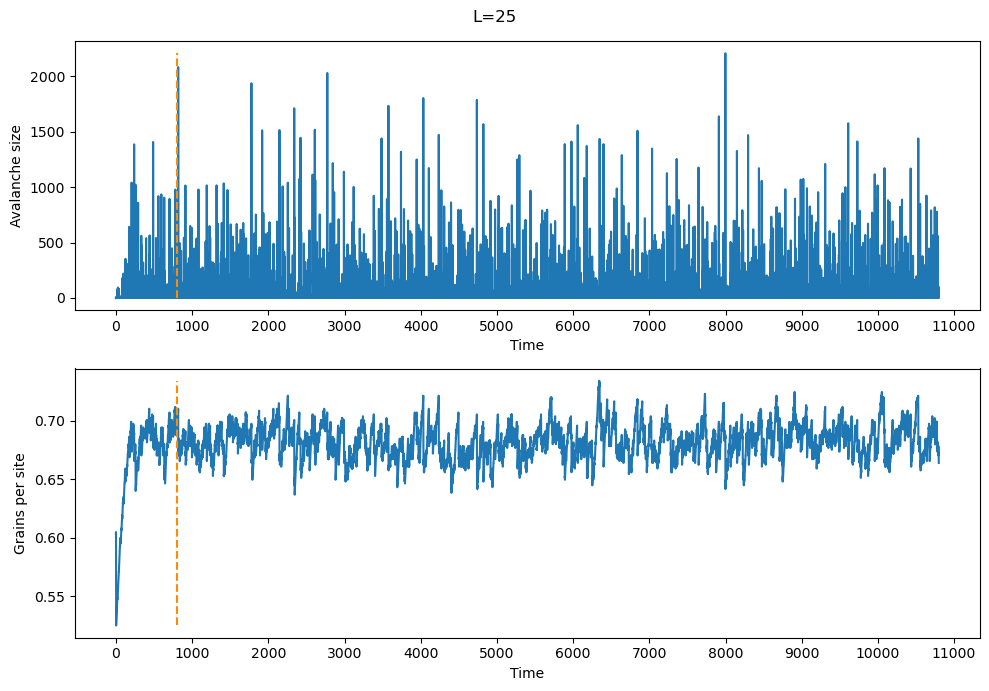

In [ ]:
# 1
L_list = [25,50,100,200]
n_min = [800,1600,4200,10**4]
n_max = [n+10**4 for n in n_min]
print(n_min,n_max)
j=0
data_sum = np.genfromtxt("Data/25_sum.txt")
soc = data_sum[:,0]
sum = data_sum[:,1]
fig,ax = plt.subplots(2,1,figsize=(10,7))
ax[0].plot(np.arange(len(soc)),soc)
ax[0].plot([n_min[j],n_min[j]],[0,max(soc)],color="darkorange",linestyle="dashed")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Avalanche size")
ax[0].set_xticks([0,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,11000])

ax[1].plot(np.arange(len(sum)),sum)
ax[1].plot([n_min[j],n_min[j]],[min(sum),max(sum)],color="darkorange",linestyle="dashed")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Grains per site")
ax[1].set_xticks([0,1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,11000])

fig.suptitle("L=25")
fig.tight_layout()
fig.savefig("prob_1.png")
plt.show()

[800, 1600, 4200, 10000] [10800, 11600, 14200, 20000]
Starting L= 25
Starting L= 50
Starting L= 100
Starting L= 200


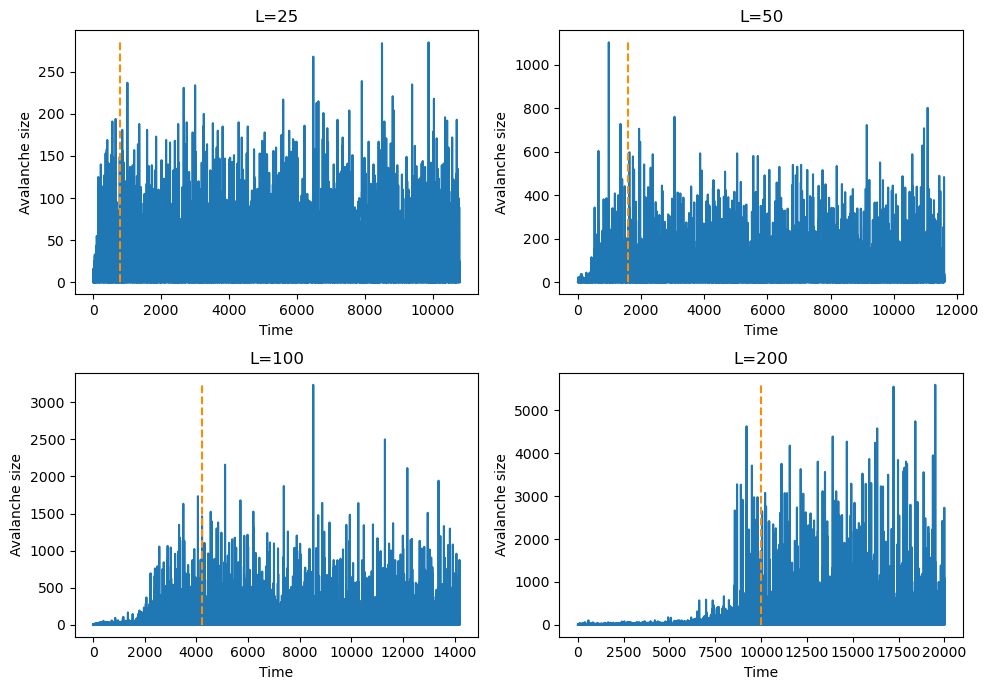

In [ ]:
# 2
L_list = [25,50,100,200]
n_min = [800,1600,4200,10**4]
n_max = [n+10**4 for n in n_min]
fig,ax = plt.subplots(2,2,figsize =(10,7))
for index,L in enumerate(L_list):
    print("Starting L=",L)
    data = sandpile(L=L,n_max=int(n_max[index]))
    axis = ax.flatten()[index]
    axis.plot(np.arange(len(data)),data)
    axis.set_title("L="+str(L))
    axis.plot([n_min[index],n_min[index]],[0,max(data)],color="darkorange",linestyle="dashed")

    axis.set_xlabel("Time")
    axis.set_ylabel("Avalanche size")
    np.savetxt("Data\\sizes_L="+str(L)+".txt",data,header='sizes')
fig.tight_layout()
plt.show()

[800, 1600, 4200, 10000] [10800, 11600, 14200, 20000]
gamma_lin= 1.3161584734312646
D_theory =  2.9246542105087743
gamma_lin= 1.2521494553039247
D_theory =  2.674331140338736
gamma_lin= 1.2813099390356506
D_theory =  2.7828407663191683


C:\Users\Silas Schack\AppData\Local\Temp\ipykernel_9188\1564606073.py:5: RuntimeWarning: invalid value encountered in log10
  return -gamma*x+np.log10(A)


gamma_lin= 1.2490959966068607
D_theory =  2.6634563019540733


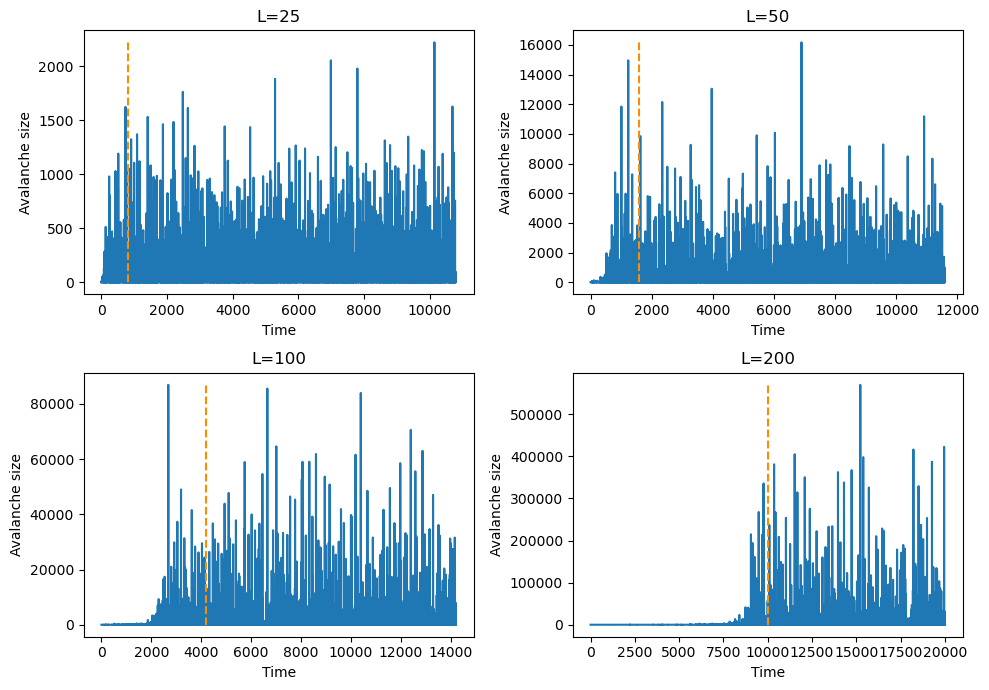

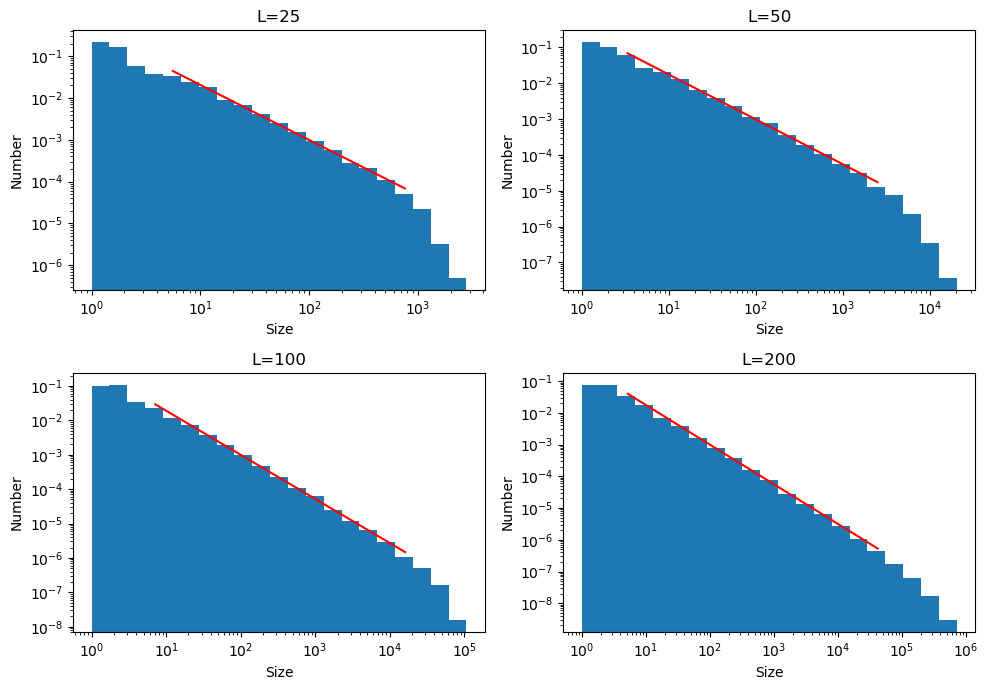

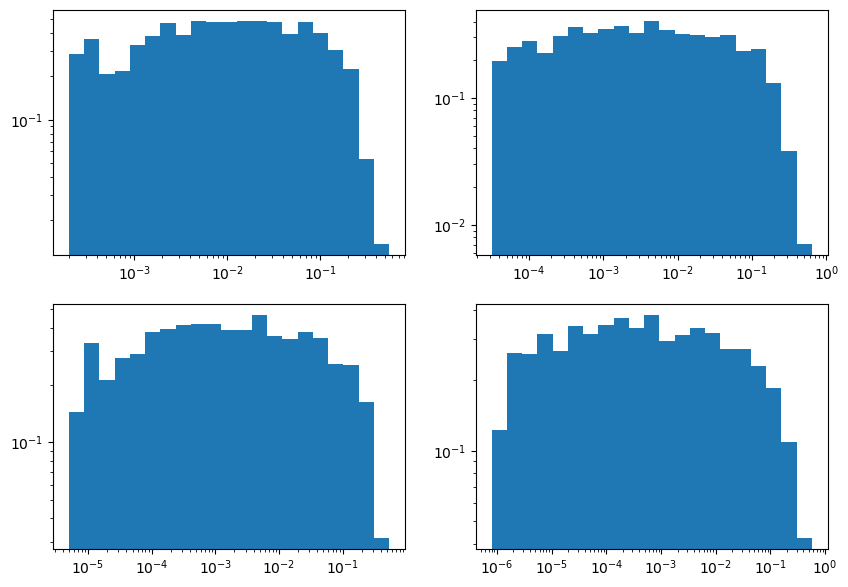

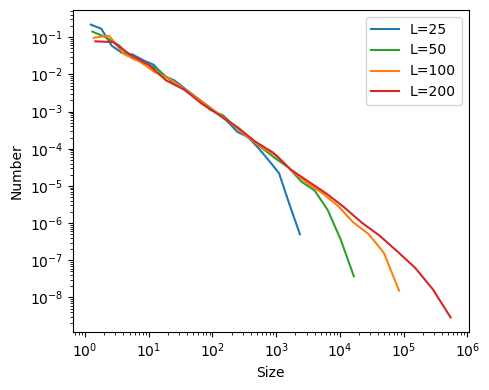

In [17]:
# plotting size destribution
L_list = [25,50,100,200]
n_min = [800,1600,4200,10**4]
n_max = [n+10**4 for n in n_min]
print(n_min,n_max)
fig_size,ax_size = plt.subplots(2,2,figsize =(10,7))
fig,ax = plt.subplots(2,2,figsize =(10,7))
fig_test,ax_test = plt.subplots(2,2,figsize =(10,7))
all_fig,all_ax = plt.subplots(1,1,figsize =(5,4))
s_cutoff_lower = [4,3,5,3]
s_cutoff_upper = [10**3,10**(3.5),2*10**4,5*10**4]
cutoff = []
gamma_list = []
colour=["tab:blue","tab:green","tab:orange","tab:red"]

for index,L in enumerate(L_list):
    axis_size = ax_size.flatten()[index]
    axis = ax.flatten()[index]
    axis_test = ax_test.flatten()[index]
    data = np.genfromtxt("Data\\sizes_L="+str(L)+".txt")

    axis_size.plot(np.arange(len(data)),data)
    axis_size.set_title("L="+str(L))
    axis_size.plot([n_min[index],n_min[index]],[0,max(data)],color="darkorange",linestyle="dashed")

    axis_size.set_xlabel("Time")
    axis_size.set_ylabel("Avalanche size")   
    # cut out zero sizes

    data = data[n_min[index]:]
    data = data[data!=0]
    cutoff.append(max(data))            # perhaps change to maximum bin instead
    bins,hist,widths = logbin_plot(data,ax=axis,num_bins=22)
  #  logbin_plot(data,ax=all_ax,num_bins=22,colour=colour[index],alpha=0.25)
    all_ax.plot(bins,hist,color=colour[index],label="L="+str(L))
    #cutoff.append(max(bins))            # changed to maximum bin value
    # cut small behavior
    bins_mask = np.logical_and(bins>s_cutoff_lower[index], bins<s_cutoff_upper[index])
    bins_cut = bins[bins_mask]
    hist_cut = hist[bins_mask]


    lin_parms,lin_cov = curve_fit(linear,np.log10(bins_cut),np.log10(hist_cut),p0=[1.23,1])

    X = np.linspace(min(bins_cut),max(bins_cut),100)

    axis.plot(X,power_law(X,*lin_parms),color="red")
    gamma_list.append(lin_parms[0])
    axis.set_xlabel("Size")
    axis.set_ylabel("Number")
    axis.set_title("L="+str(L))
    print("gamma_lin=",lin_parms[0])
    print("D_theory = ",2/(2-lin_parms[0]))

    axis_test.bar(bins/L**(2.65),hist*bins**lin_parms[0],widths/L**(2.65),color="tab:blue")
    axis_test.loglog()


fig_size.tight_layout()
fig.tight_layout()
fig_size.savefig("four_sizes.png")
fig.savefig("size_dest.png")

all_ax.loglog()
all_ax.set_xlabel("Size")
all_ax.set_ylabel("Number")
all_ax.legend()
all_fig.tight_layout()
all_fig.savefig("all_logbin.png")
plt.show()

[-2.64053474  0.47571368]


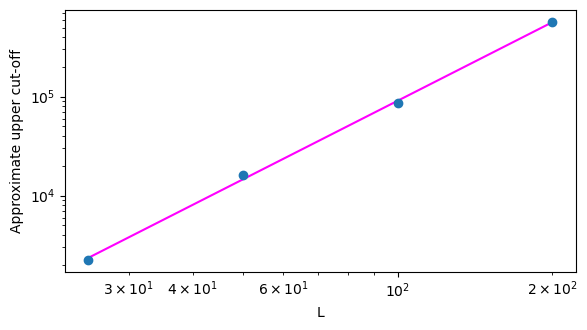

In [13]:
fig,ax = plt.subplots(1,1,figsize = (6,3.4))
ax.scatter(L_list,cutoff)
ax.loglog()
P,C = curve_fit(linear,np.log10(L_list),np.log10(cutoff))
print(P)
X = np.linspace(min(L_list),max(L_list),100)
ax.plot(X,power_law(X,*P),color="magenta",zorder=0)
ax.set_xlabel("L")
ax.set_ylabel("Approximate upper cut-off")
fig.tight_layout()
fig.savefig("cutoff_fit.png")
plt.show()

## for extracting avalanch dimension

In [9]:
N=200
soc,width = sandpile_size(N,n_max[3])
np.savetxt("size_and_width_200.txt",np.vstack((soc,width)).T,header="size,width")

In [10]:
data = np.loadtxt("size_and_width_200.txt")
soc = data[:,0]
width = data[:,1]
soc_no_zero = soc[n_min[3]:]
width_no_zero = width[n_min[3]:]

mask = soc_no_zero!=0

soc_no_zero = soc_no_zero[mask]
width_no_zero = width_no_zero[mask]

C:\Users\Silas Schack\AppData\Local\Temp\ipykernel_24080\1564606073.py:5: RuntimeWarning: invalid value encountered in log10
  return -gamma*x+np.log10(A)


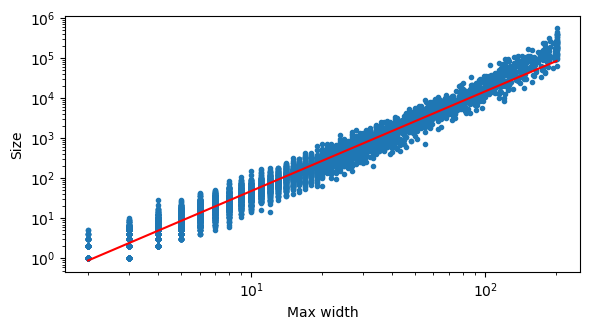

[-2.48193847  0.158995  ]


In [11]:
fig,ax = plt.subplots(1,1,figsize=(6,3.4))

ax.scatter(width_no_zero,soc_no_zero,marker ='.')
p,c = curve_fit(linear,np.log10(width_no_zero),np.log10(soc_no_zero),p0=[2,1])
x = np.linspace(min(width_no_zero),max(width_no_zero),100)
ax.plot(x,power_law(x,*p),color="red",label="Linear fit")
ax.loglog()
ax.set_xlabel("Max width")
ax.set_ylabel("Size")
fig.tight_layout()
fig.savefig("width.png")
plt.show()
print(p)


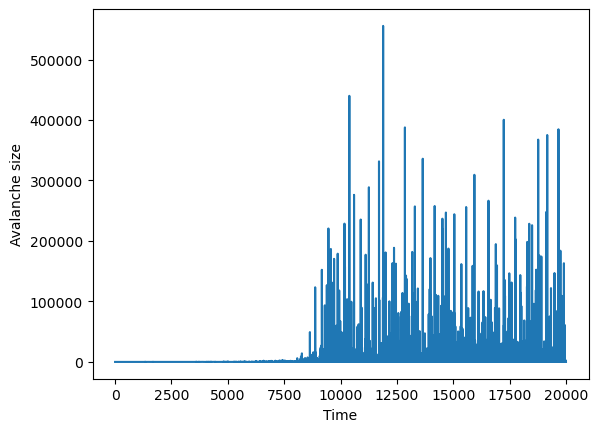

In [12]:
plt.plot(np.arange(len(soc)),soc)
plt.xlabel("Time")
plt.ylabel("Avalanche size")
plt.savefig("L=25_1.png")
plt.show()

## edge

Starting L= 25
100201
Starting L= 50
100201
Starting L= 100
100201
Starting L= 200
100201


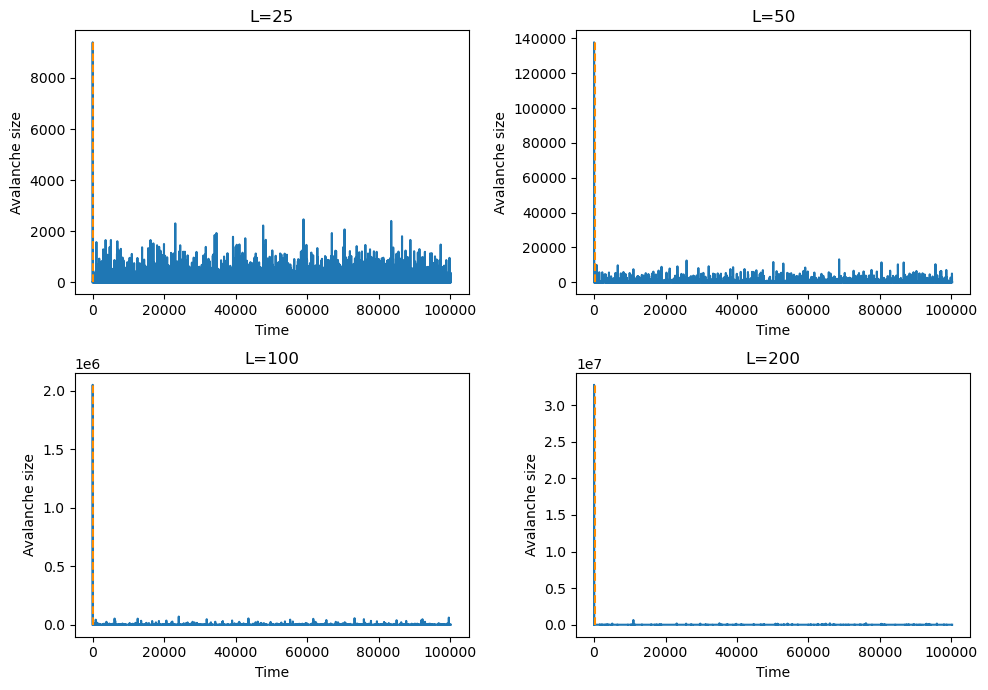

In [ ]:
# 4 edge
L_list = [25,50,100,200]
n_min = [200,200,200,200]
n_max = [n+10**5 for n in n_min]
print(n_min,n_max)
fig,ax = plt.subplots(2,2,figsize =(10,7))
for index,L in enumerate(L_list):
    print("Starting L=",L)
    data = sandpile_edge(L=L,n_max=int(n_max[index]))
    axis = ax.flatten()[index]
    axis.plot(np.arange(len(data)),data)
    axis.set_title("L="+str(L))
    axis.plot([n_min[index],n_min[index]],[0,max(data)],color="darkorange",linestyle="dashed")

    axis.set_xlabel("Time")
    axis.set_ylabel("Avalanche size")
    print(len(data))
    np.savetxt("Data\\sizes_edge_L="+str(L)+".txt",data)
fig.tight_layout()
plt.show()

[200, 200, 200, 200] [100200, 100200, 100200, 100200]
gamma_lin= 1.629826774816005
gamma_lin= 1.658192909176475
gamma_lin= 1.6700123213515758
gamma_lin= 1.6230395709070204


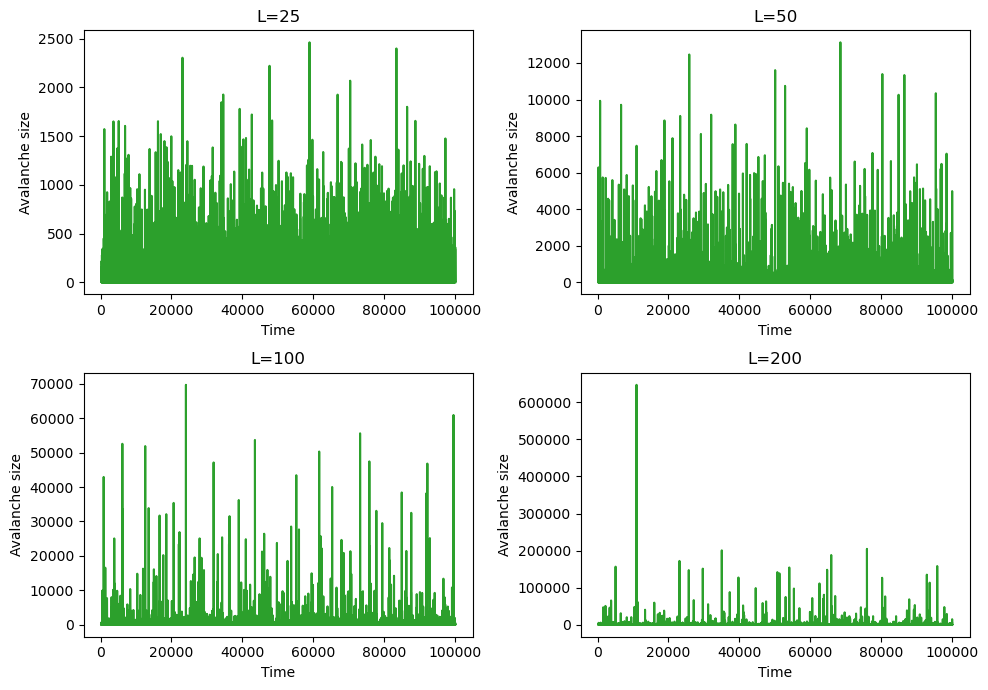

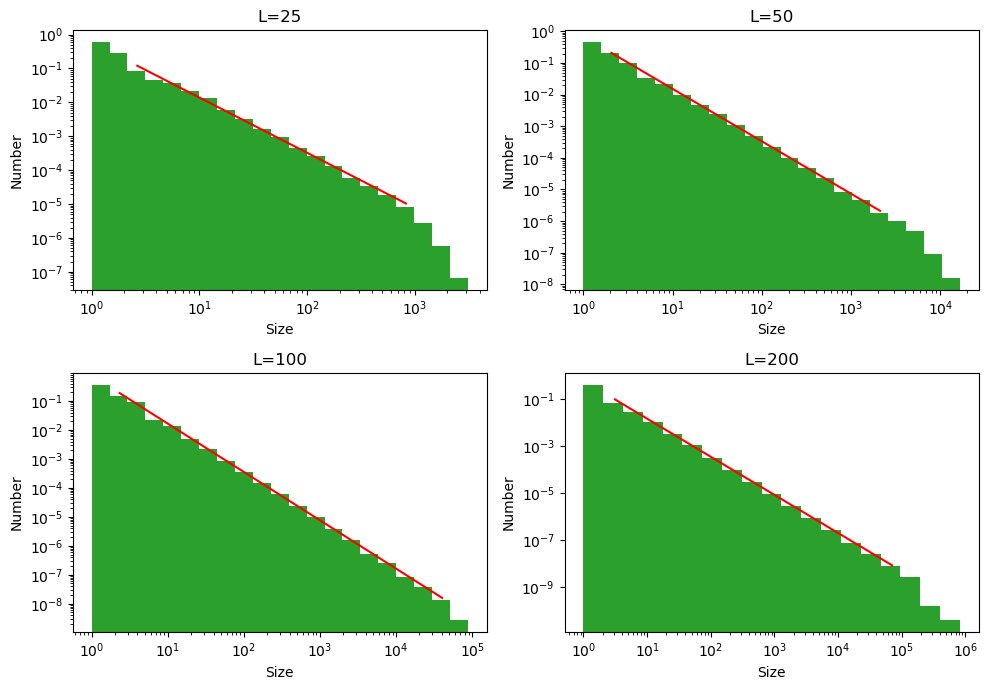

In [18]:
# plotting size destribution
L_list = [25,50,100,200]
n_min = [200,200,200,200]
n_max = [n+10**5 for n in n_min]
print(n_min,n_max)
fig_size,ax_size = plt.subplots(2,2,figsize =(10,7))
fig,ax = plt.subplots(2,2,figsize =(10,7))
#fig_test,ax_test = plt.subplots(2,2,figsize =(10,7))
s_cutoff_lower = [2,2,2,2]
s_cutoff_upper = [10**3,10**(3.5),0.5*10**5,10**5]
cutoff_edge = []
gamma_list_edge = []
num_bins = [22,22,22,20]

for index,L in enumerate(L_list):
    axis_size = ax_size.flatten()[index]
    axis = ax.flatten()[index]
    #axis_test = ax_test.flatten()[index]
    data = np.genfromtxt("Data\\sizes_edge_L="+str(L)+".txt")

    axis_size.plot(np.arange(len(data))[n_min[index]:],data[n_min[index]:],color="tab:green")
    # axis_size.plot(np.arange(len(data)),data)
    axis_size.set_title("L="+str(L))
    # axis_size.plot([n_min[index],n_min[index]],[0,max(data)],color="darkorange",linestyle="dashed")

    axis_size.set_xlabel("Time")
    axis_size.set_ylabel("Avalanche size")   
    # cut out zero sizes

    data = data[n_min[index]:]
    data = data[data!=0]
    cutoff_edge.append(max(data))            # perhaps change to maximum bin instead

    bins,hist = logbin_plot(data,ax=axis,num_bins=num_bins[index],colour="tab:green")[:2]
    #cutoff.append(max(bins))            # changed to maximum bin value
    # cut small behavior
    bins_mask = np.logical_and(bins>s_cutoff_lower[index], bins<s_cutoff_upper[index])
    bins_cut = bins[bins_mask]
    hist_cut = hist[bins_mask]

    #cutoff_mask = bins <= L_cutoff_list[index]
    #bins_cut = bins[cutoff_mask]
    #hist_cut = hist[cutoff_mask]
    #print(min(bins_cut))

    lin_parms,lin_cov = curve_fit(linear,np.log10(bins_cut),np.log10(hist_cut))
    # parms_cutoff, cov_cutoff = curve_fit(lin_plus_cut, np.log10(bins),np.log10(hist))

    #X = np.linspace(min(bins),max(bins),1000)
    X = np.linspace(min(bins_cut),max(bins_cut),100)

    #axis_test.scatter(np.log10(bins),np.log10(hist))

    #YY = np.linspace(min(np.log10(bins)),max(np.log10(bins)),1000)
    
    #axis_test.plot(YY,lin_plus_cut(YY,*parms_cutoff))

    # axis.plot(X,power_cutoff(X,*parms_cutoff),color="green")
    axis.plot(X,power_law(X,*lin_parms),color="red")
    gamma_list_edge.append(lin_parms[0])
    axis.set_xlabel("Size")
    axis.set_ylabel("Number")
    axis.set_title("L="+str(L))
    print("gamma_lin=",lin_parms[0])
    # print("D=",np.log(parms_cutoff[-1])/np.log(L))
fig_size.tight_layout()
fig.tight_layout()
fig_size.savefig("four_sizes_edge.png")
fig.savefig("size_dest_edge.png")
plt.show()

[-2.6522603  0.4322402]


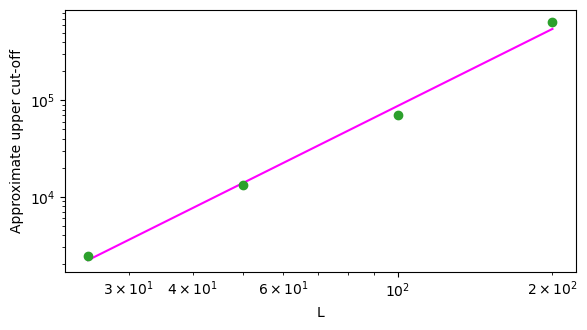

In [14]:
fig,ax = plt.subplots(1,1,figsize = (6,3.4))
ax.scatter(L_list,cutoff_edge,color="tab:green")
ax.loglog()
P,C = curve_fit(linear,np.log10(L_list),np.log10(cutoff_edge))
print(P)
X = np.linspace(min(L_list),max(L_list),100)
ax.plot(X,power_law(X,*P),color="magenta",zorder=0)
ax.set_xlabel("L")
ax.set_ylabel("Approximate upper cut-off")
fig.tight_layout()
fig.savefig("cutoff_fit_edge.png")
plt.show()

### Edge and width for L=200

In [19]:
L_list = [25,50,100,200]
n_min = [200,200,200,200]
n_max = [n+10**5 for n in n_min]
N=200
soc,width = sandpile_edge_size(N,n_max[3]*5)
np.savetxt("edge_width_200.txt",np.vstack((soc,width)).T,header="size,width")

In [20]:
L_list = [25,50,100,200]
n_min = [200,200,200,200]
n_max = [n+10**5 for n in n_min]
print(n_min,n_max)
data = np.loadtxt("edge_width_200.txt")
soc = data[:,0]
width = data[:,1]
soc_no_zero = soc[n_min[3]:]
width_no_zero = width[n_min[3]:]

mask = soc_no_zero!=0

soc_no_zero = soc_no_zero[mask]
width_no_zero = width_no_zero[mask]

[200, 200, 200, 200] [100200, 100200, 100200, 100200]


C:\Users\Silas Schack\AppData\Local\Temp\ipykernel_24080\1564606073.py:5: RuntimeWarning: invalid value encountered in log10
  return -gamma*x+np.log10(A)


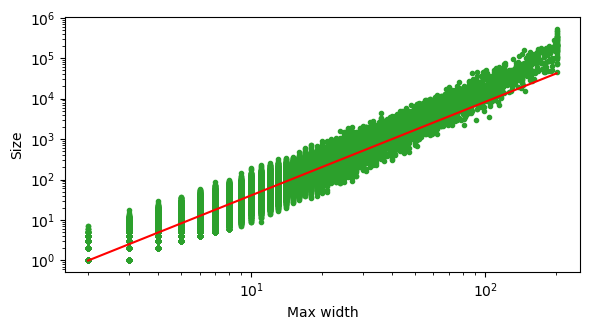

[-2.31017434  0.19967562]


In [27]:
fig,ax = plt.subplots(1,1,figsize=(6,3.4))

ax.scatter(width_no_zero,soc_no_zero,marker ='.',color="tab:green")
p,c = curve_fit(linear,np.log10(width_no_zero),np.log10(soc_no_zero),p0=[2,1])
x = np.linspace(min(width_no_zero),max(width_no_zero),100)
ax.plot(x,power_law(x,*p),color="red",label="Linear fit")
ax.loglog()
ax.set_xlabel("Max width")
ax.set_ylabel("Size")
fig.tight_layout()
fig.savefig("width_edge.png")
plt.show()
print(p)